In [25]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn import metrics     
from sklearn.tree import DecisionTreeClassifier  
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier  
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder , StandardScaler


from sklearn.model_selection import GridSearchCV , RandomizedSearchCV

In [26]:
data = pd.read_csv('../dataset/CreditScoring.csv')
data.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [27]:
data.tail()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
5955,0,88900,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347
5956,0,89000,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971
5957,0,89200,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590
5958,0,89800,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882
5959,0,89900,48811.0,88934.0,DebtCon,Other,15.0,0.0,0.0,219.601002,0.0,16.0,34.571519


In [28]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   str    
 5   JOB      5681 non-null   str    
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), str(2)
memory usage: 605.4 KB


In [29]:
data.columns

Index(['BAD', 'LOAN', 'MORTDUE', 'VALUE', 'REASON', 'JOB', 'YOJ', 'DEROG',
       'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC'],
      dtype='str')

In [30]:
data.shape

(5960, 13)

In [31]:
data.describe()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,18607.969799,73760.817200,101776.048741,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,89900.000000,399550.000000,855909.000000,41.000000,10.000000,15.000000,1168.233561,17.000000,71.000000,203.312149


In [32]:
data.isnull().sum()

BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB         279
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64

In [33]:
data.duplicated().sum()

np.int64(0)

In [34]:
print("Number of unique Reason columns " , data['REASON'].nunique())
print("Number of unique Job columns ", data['JOB'].nunique())

Number of unique Reason columns  2
Number of unique Job columns  6


In [35]:
unique_BAD1 = (data['BAD']== 1).sum()
print("Number of Bad = 1" , unique_BAD1)

unique_BAD0 = (data['BAD']== 0).sum()

print("Number of Bad = 0 " , unique_BAD0)

Number of Bad = 1 1189
Number of Bad = 0  4771


<Axes: xlabel='JOB', ylabel='LOAN'>

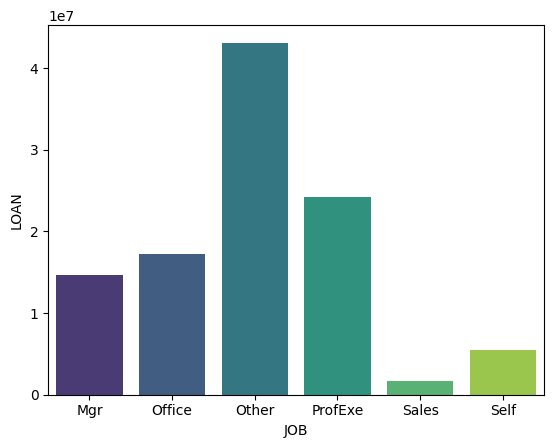

In [36]:
loan_by_job = data.groupby('JOB')['LOAN'].sum().reset_index()

sns.barplot(data = loan_by_job , x = 'JOB' , y = 'LOAN' , palette = 'viridis' , hue = 'JOB' , legend = False)

<Axes: xlabel='REASON', ylabel='LOAN'>

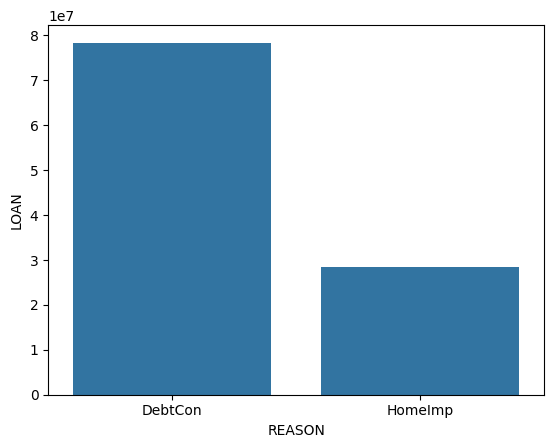

In [37]:
loan_by_reason = data.groupby("REASON")["LOAN"].sum().reset_index()

sns.barplot(data = loan_by_reason , x = "REASON" , y = "LOAN" , hue =None , legend= False)

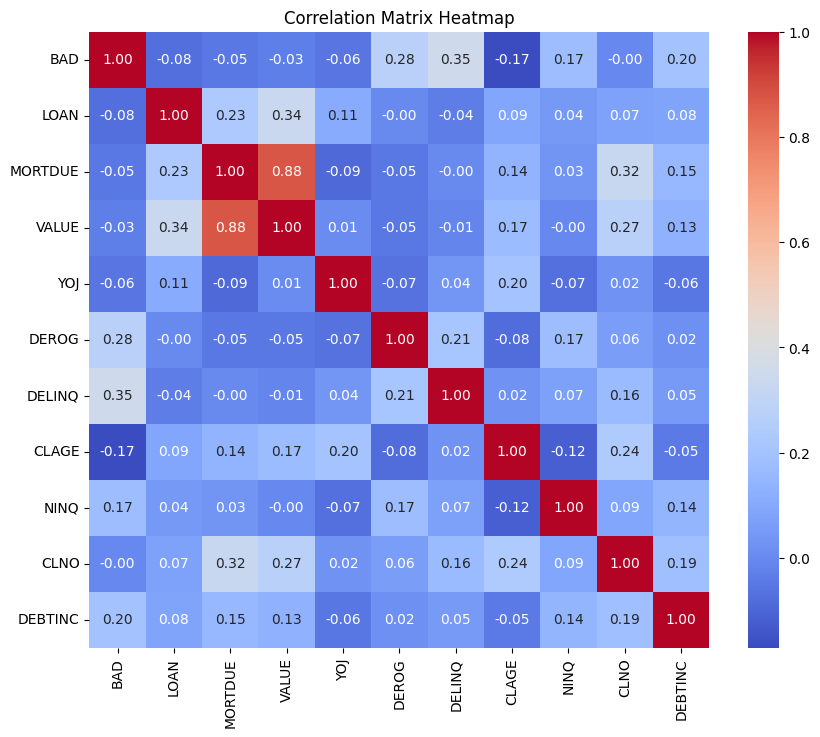

In [38]:
numerical_dataset = data.select_dtypes(include = [np.number])
correlation_matrix = numerical_dataset.corr(method='pearson')

plt.figure(figsize=(10 , 8 ))
sns.heatmap(correlation_matrix , annot= True , cmap= "coolwarm" , fmt = '.2f')
plt.title("Correlation Matrix Heatmap")
plt.show()

In [39]:
X= data.drop("BAD" , axis = 1)
y = data["BAD"]

cat_cols = X.select_dtypes(include= ['object']).columns.tolist()
num_cols = X.select_dtypes(include = ['int64' , 'float64']).columns.tolist()

print(f"Categorical columns : , {cat_cols}")
print(f"Numerical columns :  , {num_cols}")

Categorical columns : , ['REASON', 'JOB']
Numerical columns :  , ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']


/tmp/ipykernel_41946/2420911629.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include= ['object']).columns.tolist()


In [40]:
num_transformer = Pipeline(steps = [
    ('impute' , SimpleImputer(strategy= 'median')),
    ('scaler' , StandardScaler())
])

cat_tranformer = Pipeline(steps = [
    ('impute' , SimpleImputer(strategy= 'most_frequent')),
    ('onehot' , OneHotEncoder(handle_unknown='ignore' ,sparse_output= False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num' , num_transformer , num_cols),
        ('cat' , cat_tranformer , cat_cols)
    ]
)

In [41]:
print(X.columns)
X_train ,X_test , y_train , y_test = train_test_split(X , y , test_size= 0.33 , random_state= 42 , stratify=y)

Index(['LOAN', 'MORTDUE', 'VALUE', 'REASON', 'JOB', 'YOJ', 'DEROG', 'DELINQ',
       'CLAGE', 'NINQ', 'CLNO', 'DEBTINC'],
      dtype='str')


In [42]:
def confusion_matrix_sns(y_true , y_pred):
    conf =metrics.confusion_matrix(y_true , y_pred)
    sns.heatmap(conf , annot= True , fmt = 'd' , cmap = 'Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

In [47]:
def pipeline(preproc, model , model_name):
    clf = Pipeline(steps=[
        ('preprocessor' , preproc),
        ('classifier' , model)
    ])
    clf.fit(X_train , y_train)

    print("-"* 60)
    print(f"Metrics of the {model_name} algorithm ")
    print("-"* 60)
    y_predicted = clf.predict(X_test)

    accuracy = metrics.accuracy_score(y_test , y_predicted )
    print("Accuracy : " , accuracy)

    f1_score = metrics.f1_score(y_test , y_predicted  )
    print("F1 - Score :" , f1_score)

    precision = metrics.precision_score(y_test , y_predicted )
    print("Precision : " ,precision )

    recall =metrics.recall_score(y_test , y_predicted   ) 
    print("Recall : " , recall )

    confusion_matrix_sns(y_test , y_predicted)



------------------------------------------------------------
Metrics of the Decision Tree Classifier algorithm 
------------------------------------------------------------
Accuracy :  0.8551093035078801
F1 - Score : 0.6264744429882044
Precision :  0.6442048517520216
Recall :  0.6096938775510204


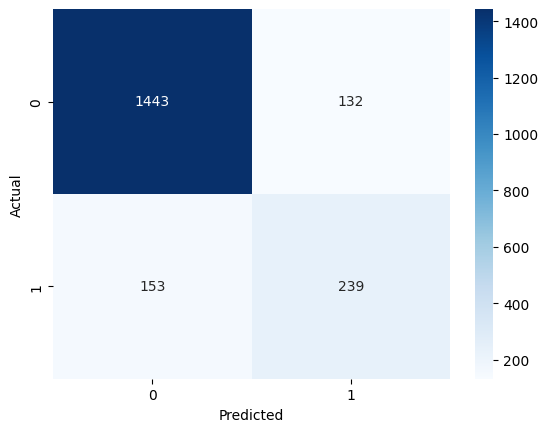

In [48]:
pipeline(preprocessor , DecisionTreeClassifier() , "Decision Tree Classifier")


------------------------------------------------------------
Metrics of the Random Forest Classifier algorithm 
------------------------------------------------------------
Accuracy :  0.9028978139298424
F1 - Score : 0.7127819548872181
Precision :  0.8681318681318682
Recall :  0.6045918367346939


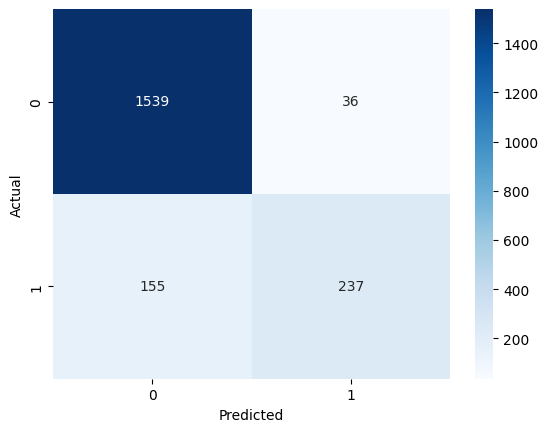

In [49]:
random_forest = RandomForestClassifier(
    n_estimators= 100, 
    min_samples_split= 2, 
    min_samples_leaf= 1, 
    max_depth= None, 
    class_weight= 'balanced_subsample'
)

pipeline(preprocessor , random_forest , "Random Forest Classifier")


------------------------------------------------------------
Metrics of the XG Boost Classifier algorithm 
------------------------------------------------------------
Accuracy :  0.922216573462125
F1 - Score : 0.7854137447405329
Precision :  0.8722741433021807
Recall :  0.7142857142857143


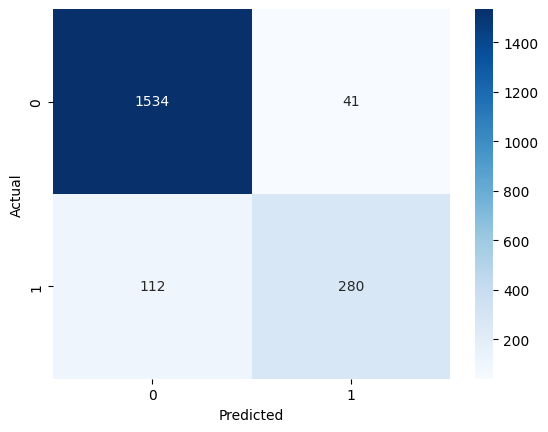

In [50]:
xgboost = XGBClassifier(
    # 'binary:logistic',
    # eval_metric = 'auc',
    # booster = 'gbtree'
    learning_rate = 0.1,
    n_estimators = 1000,
    max_depth = 10,
    # min_child_weight = 0g
    max_delta_step = 1,
    eval_metric = 'aucpr',
    objective = 'binary:logistic'

)

pipeline(preprocessor , xgboost , "XG Boost Classifier")